Run this cell to install genexp into your environment if you haven't already done so (e.g. on Colab)

In [ ]:
!pip install https://github.com/Komod0D/flow-expansion.git

In [1]:
from matplotlib import pyplot as plt
from genexp.models import DiffusionModel

from tqdm.notebook import tqdm
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from pytorch_lightning import LightningModule, Trainer

from genexp.sampling import VPSDE, EulerMaruyamaSampler
from genexp.trainers.genexp import FlowExpansionTrainer

In [2]:
class LightningDiffusion(LightningModule):
    def __init__(self, model: DiffusionModel):
        super().__init__()
        self.model = model

    
    def forward(self, *args, **kwargs):
        return self.model(*args, **kwargs)
    

    def training_step(self, batch, batch_idx):
        x0, = batch
        t = torch.rand(x0.shape[0]).to(x0.device)
        alpha, sig = self.model.sde.get_alpha_sigma(t[:, None])
        eps = torch.randn(x0.shape).to(x0.device)

        xt = torch.sqrt(alpha) * x0 + sig * eps

        eps_pred = self(xt, t[:, None])

        loss = torch.mean((eps - eps_pred)**2) / 2.
        self.log('loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

Training base model

In [ ]:
x0 = torch.randn((50000, 2))
x1 = torch.randn((5000, 2)) * 0.3 + 3
x2 = torch.randn((5000, 2)) * 0.3 - 3
dataset = torch.vstack((x0, x1))

network = nn.Sequential(
    nn.Linear(3, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 2)
)

sde = VPSDE(0.1, 12)

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
model = DiffusionModel(network, sde).to(device)
pl_model = LightningDiffusion(model)


dl = DataLoader(TensorDataset(dataset), batch_size=128, shuffle=True)

trainer = Trainer(max_epochs=10)
trainer.fit(pl_model, dl)
torch.save(model.model.state_dict(), 'gauss_model.pth')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/komodo/Documents/uni/thesis/flow-expansion/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enabl

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ DiffusionModel │  396 K │ train │     0 │
└───┴───────┴────────────────┴────────┴───────┴───────┘

Trainable params: 396 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 396 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/komodo/Documents/uni/thesis/flow-expansion/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/komodo/Documents/uni/thesis/flow-expansion/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Loading base model

In [3]:
network = nn.Sequential(
    nn.Linear(3, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 2)
)

sde = VPSDE(0.1, 12)

model = DiffusionModel(network, sde)
pl_model = LightningDiffusion(model)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.model.load_state_dict(torch.load('gauss_model.pth'))

<All keys matched successfully>

Visualize pre-trained model density (takes a few minutes to sample enough poins)

In [ ]:
x0 = torch.randn((50000, 2))
x1 = torch.randn((5000, 2)) * 0.3 + 3
dataset = torch.vstack((x0, x1))

sampler = EulerMaruyamaSampler(model.to(device), data_shape=(2,), device=device)
samples_base = []
for i in tqdm(range(50000 // 128)):
    trajs, ts = sampler.sample_trajectories(N=128, T=50, device=device)
    samples_base.append(trajs[-1].full.detach().cpu())

samples_base = torch.vstack(samples_base)

plt.hist(dataset[:, 0], bins=150, alpha=0.3, density=True, label='data density')
plt.hist(samples_base[:, 0], bins=50, density=True, alpha=0.5, label='pre-trained model density')
plt.show()

Initialize Flow Expansion trainer

In [4]:
from omegaconf import OmegaConf
import copy

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
config = OmegaConf.load('configs/example_fe.yaml')
sampler = EulerMaruyamaSampler(model, data_shape=(2,), device=device)
model = model.to(device)
fe_trainer = FlowExpansionTrainer(config, copy.deepcopy(model), copy.deepcopy(model), device=device, sampler=sampler)

Main Flow Expansion loop

In [6]:
for k in tqdm(range(config.num_md_iterations)):
    fe_trainer.expand()

    for i in range(config.adjoint_matching.num_iterations):
        dataset = fe_trainer.generate_dataset()
        fe_trainer.finetune(dataset, steps=config.adjoint_matching.finetune_steps)
    

    if fe_trainer.grad_constraint is not None and fe_trainer.eta > 0.:
        fe_trainer.project()

        for i in range(config.adjoint_matching.num_iterations):
            dataset = fe_trainer.generate_dataset()
            fe_trainer.finetune(dataset, steps=config.adjoint_matching.finetune_steps)


    fe_trainer.update_base_model()

  0%|          | 0/3 [00:00<?, ?it/s]

Visualizing fine-tuned density (takes a few minutes to sample enough points)

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/390 [00:00<?, ?it/s]

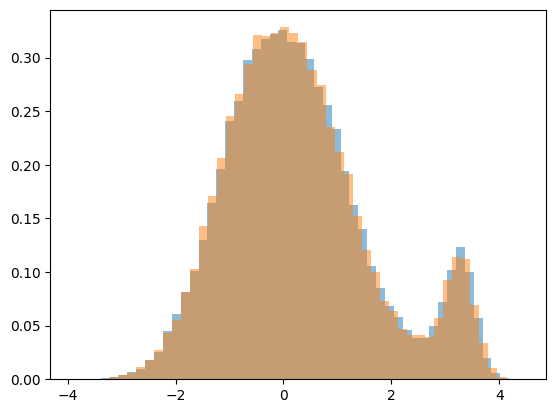

In [ ]:
sampler.model = fe_trainer.fine_model

samples_fine = []
for i in tqdm(range(50000 // 128)):
    trajs, ts = sampler.sample_trajectories(N=128, T=50, device=device)
    samples_fine.append(trajs[-1].full.detach().cpu())

samples_fine = torch.vstack(samples_fine)

sampler.model = fe_trainer.fine_model

samples_base = []
for i in tqdm(range(50000 // 128)):
    trajs, ts = sampler.sample_trajectories(N=128, T=50, device=device)
    samples_base.append(trajs[-1].full.detach().cpu())

samples_base = torch.vstack(samples_base)

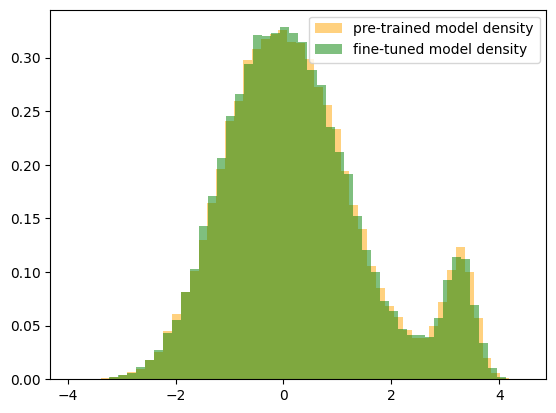

In [16]:
plt.hist(samples_base[:, 0], bins=50, density=True, alpha=0.5, label='pre-trained model density', color='orange')
plt.hist(samples_fine[:, 0], bins=50, density=True, alpha=0.5, label='fine-tuned model density', color='green')
plt.legend()
plt.show()